*Author: Luke Sherman*

*Published: 2025-02-20*

*Last Updated: 2025-02-20*

In [1]:
import os
import time

import geopandas as gpd
import pandas as pd
import redivis
from cartopy.io import shapereader
from matplotlib import pyplot as plt



## Mosaiks Tutorial - Querying Redivis for native resolution grid features

The first step in using MOSAIKS is downloading a set of features. This tutorial will demonstrate how to query Redivis for native resolution (.01 x .01 degree) grid features over a small geographic area. 

For many users and for global scale analyses, it may be preferable to download coarsened global grid files or ADM aggregations. See [api.mosaiks.org](api.mosaiks.org) for more information.


### Step 1 - Make a Redivis account

Go to [Redivis.com](https://redivis.com/) and create an account. Once you have a Redivis account, you will have full access to the MOSAIKS data on Redivis.

### Step 2 - Access the table

In [ ]:
## These variables will not change
user = redivis.user("SDSS_data_repository")
dataset = user.dataset("mosaiks")

#### Now, let's query the dataset so that it prompts us to authenticate
For more information on authnetication with Redivis see: https://apidocs.redivis.com/rest-api/authorization


In [4]:
## Now, let's run this first query. This will ask us to use a browser

#dataset.list_tables() # This output is hard to read

## Modification of the above so that it is a bit easier to read
[item.name for item in dataset.list_tables()]

Please authenticate with your Redivis account. Opening browser to:
https://redivis.com/oauth/authorize?user_code=5a3a273ec3ecb4e71550aa48f0b836e7


['0.1 x 0.1 Deg - Area Weighted',
 '0.1 x 0.1 Deg - Pop weighted',
 '0.25. x 0.25 Deg Grid',
 'mosaiks_2019_planet',
 '0.1 x 0.1 Deg - Pop Weighted - TABLE',
 '0.1 x 0.1 Deg - Area Weighted - TABLE',
 '1 x 1 Deg Grid',
 'Administrative Region Aggregations']

Some of these tables are just used for indexing of uploaded files. There are 3 that may be queried for features:

1. 'mosaiks_2019_planet' : This table contains the global, native resolution features (.01 x .01 degree).
2. 'coarsened_0.1_x_0.1_deg_area_weighted_mosaiks' : This table contains the features coarsend to .1 x .1 degree using area weights.
3. 'coarsened_0.1_x_0.1_deg_pop_weighted_mosaiks' : This table contains the features coarsend to .1 x .1 degree using population weights from GHS-POP.

In this notebook, we're going to query for native resolution features


In [5]:
table_name = "mosaiks_2019_planet" # Table name for native resolution grid features
table = dataset.table(table_name)

### Step 3 - Get the bounds for the area we want to query

We're going to load boundaries from Natural Earth using cartopy. Alternatively, you can also just read in a shapefile locally or import your own geospatial data.

Let's suppose that we're interested in Nebraska. This is an ADM1 region, so we will need an ADM1 shapefile.

In [ ]:

resolution = '50m' #Coarse resolution
category = 'cultural'
#name = 'admin_0_countries'

name = 'admin_1_states_provinces'
shpfilename = shapereader.natural_earth(resolution, category, name)

geo_df = gpd.read_file(shpfilename)

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
0,Admin-1 scale rank,2,AUS-2651,2651,AU-WA,NaN,AU,6,Western Australia,NaN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((113.13181 -25.95199, 113.14823..."
1,Admin-1 scale rank,2,AUS-2650,2650,AU-NT,NaN,AU,6,Northern Territory,NaN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((129.00196 -25.99901, 129.00196..."
2,Admin-1 scale rank,2,AUS-2655,2655,AU-SA,NaN,AU,3,South Australia,NaN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((129.00196 -31.69266, 129.00196..."
3,Admin-1 scale rank,2,AUS-2657,2657,AU-QLD,NaN,AU,5,Queensland,NaN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((138.00196 -25.99901, 138.00174..."
4,Admin-1 scale rank,2,AUS-2660,2660,AU-TAS,NaN,AU,5,Tasmania,NaN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((147.31246 -43.28038, 147.34238..."


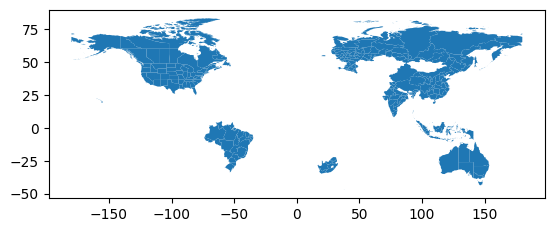

In [7]:
geo_df.plot() ## This looks like it has complete data for the US at least.
geo_df.head()

In [61]:
ri_shape = geo_df[geo_df["name"].str.contains("rhode island", case=False) ]  # Search, not case sensitive

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
88,Admin-1 scale rank,2,USA-3539,3539,US-RI,http://en.wikipedia.org/wiki/Rhode_Island,US,6,Rhode Island,State of Rhode Island and Providence Plantatio...,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-71.84235 41.33551, -71.82987 ..."


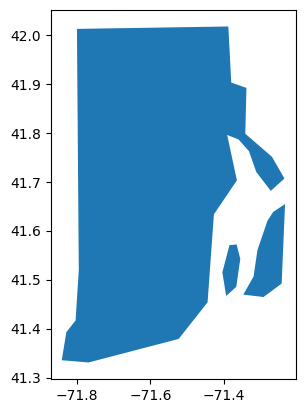

In [62]:
ri_shape.plot()
ri_shape.head()

This looks like the area we wanted to query! Now we just want the bounding box:

In [63]:
xmin, ymin, xmax, ymax = ri_shape.total_bounds

### Step 4 - Query Redivis for the data

In [67]:
wkt = ri_shape.geometry.to_wkt()

In [68]:
start_time = time.time()

# In the below, we are using a standard SQL query. 
query = dataset.query(f""" 
    SELECT * 
    FROM {table_name}
    WHERE lon BETWEEN {xmin} AND {xmax}
      AND lat BETWEEN {ymin} AND {ymax}
      AND ST_CONTAINS(
        ST_GEOGFROMTEXT('{wkt}'),
        ST_GEOGPOINT(lon, lat)
      )
""")
df = query.to_pandas_dataframe()
end_time = time.time()

print(f"Time elapsed = { (end_time-start_time)/60} minutes")

Traceback (most recent call last):
  File "/var/folders/sn/h82qf8ws0016_fgmpp88gfhc0000gn/T/ipykernel_82842/4212128260.py", line 14, in <module>
    df = query.to_pandas_dataframe()
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
APIError: [400 invalid_request] Syntax error: Unclosed string literal at [7:25]


In [ ]:
ri_shape = geo_df[geo_df["name"].str.contains("rhode island", case=False)]
xmin, ymin, xmax, ymax = ri_shape.total_bounds

ri_geom = ri_shape.geometry.union_all()   # single (Multi)Polygon
wkt = ri_geom.wkt                         # string

start_time = time.time()
query = dataset.query(f"""
    SELECT *
    FROM {table_name}
    WHERE lon BETWEEN {xmin} AND {xmax}
      AND lat BETWEEN {ymin} AND {ymax}
      AND ST_CONTAINS(
            ST_GEOGFROMTEXT('{wkt}'),
            ST_GEOGPOINT(lon, lat)
          )
""")
df = query.to_pandas_dataframe()
end_time = time.time()

print(f"Time elapsed = {(end_time - start_time)/60} minutes")

Time elapsed = 2.760768783092499 minutes


In [19]:
query

"\nSELECT *\nFROM mosaiks_2019_planet\nWHERE lon BETWEEN -104.02886245827645 AND -95.34668012024153\n  AND lat BETWEEN 40.001124343824216 AND 43.00140277858827\n  AND ST_CONTAINS(\n        ST_GEOGFROMTEXT('<bound method GeoSeries.to_wkt of 78    POLYGON ((-102.02449 40.00112, -102.02454 40.1...\nName: geometry, dtype: geometry>'),\n        ST_GEOGPOINT(lon, lLat)\n      )\n"

In [71]:
df


,lon,lat,shapeGroup,adm2_shapeID_geoBoundaries,adm1_shapeID_geoBoundaries,X_0,X_1,X_2,X_3,X_4,...,X_3990,X_3991,X_3992,X_3993,X_3994,X_3995,X_3996,X_3997,X_3998,X_3999
0,-71.295,41.495,<NA>,<NA>,<NA>,0.143599,0.23856,0.126441,0.024087,0.171032,...,0.357649,0.326168,0.70772,0.584753,0.318845,0.679609,1.692924,0.408835,0.395021,0.201624
1,-71.305,41.495,<NA>,<NA>,<NA>,0.337055,0.475876,0.262035,0.060762,0.440105,...,0.902685,0.730791,1.573408,1.314687,0.824208,1.693693,3.137611,0.911575,0.941954,0.442733
2,-71.365,41.555,<NA>,<NA>,<NA>,0.113759,0.220534,0.116344,0.016849,0.141814,...,0.260664,0.282529,0.730412,0.464742,0.236436,0.539945,1.713779,0.390667,0.197767,0.214246
3,-71.375,41.705,<NA>,<NA>,<NA>,0.258165,0.396226,0.215975,0.043806,0.336815,...,0.651562,0.5901,1.30674,1.073906,0.638203,1.265679,2.596281,0.748977,0.707019,0.367809
4,-71.395,41.805,<NA>,<NA>,<NA>,0.07375,0.131593,0.041283,0.039722,0.098191,...,0.17908,0.145749,0.262474,0.24215,0.205007,0.394376,0.5703,0.251273,0.259997,0.102763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2757,-71.315,41.755,USA,52423323B87258541323822,66186276B98073251815399,0.106843,0.180724,0.105532,0.010023,0.153297,...,0.261201,0.29531,0.714229,0.568689,0.300411,0.576904,1.362718,0.368776,0.315401,0.205045
2758,-71.315,41.765,USA,52423323B87258541323822,66186276B98073251815399,0.056178,0.094994,0.038837,0.005801,0.058655,...,0.065294,0.058488,0.24945,0.177369,0.079993,0.23786,0.583295,0.167923,0.108904,0.051508
2759,-71.305,41.765,USA,52423323B87258541323822,66186276B98073251815399,0.087472,0.09934,0.065016,0.00363,0.079576,...,0.087705,0.102828,0.329561,0.252119,0.114638,0.268892,0.647665,0.157461,0.115731,0.071332
2760,-71.325,41.755,USA,52423323B87258541323822,66186276B98073251815399,0.118678,0.241168,0.131419,0.024573,0.166611,...,0.28409,0.31126,0.831748,0.671787,0.314155,0.69546,1.672665,0.592507,0.428266,0.251776


In [50]:
df_copy = df.copy()
df_copy = df_copy.iloc[0:1000]
df_copy 

,lon,lat,shapeGroup,adm2_shapeID_geoBoundaries,adm1_shapeID_geoBoundaries,X_0,X_1,X_2,X_3,X_4,...,X_3990,X_3991,X_3992,X_3993,X_3994,X_3995,X_3996,X_3997,X_3998,X_3999
0,-97.885,40.445,USA,52423323B24655364564694,66186276B73402293045483,0.066178,0.136164,0.069699,0.021117,0.066384,...,0.109358,0.108318,0.286434,0.163436,0.080649,0.210974,0.822765,0.175379,0.097604,0.07438
1,-97.625,42.735,USA,52423323B21307284690044,66186276B73402293045483,0.034916,0.057392,0.037175,0.001543,0.035531,...,0.00881,0.019238,0.092073,0.058509,0.01073,0.065192,0.298756,0.045994,0.00718,0.020888
2,-103.885,41.965,USA,52423323B66361254084012,66186276B73402293045483,0.054087,0.103625,0.062232,0.010082,0.073504,...,0.092447,0.118829,0.238474,0.210512,0.122803,0.352731,0.60088,0.215431,0.088803,0.090859
3,-101.315,42.945,USA,52423323B98864499560077,66186276B73402293045483,0.11677,0.270773,0.051237,0.097767,0.179046,...,0.155651,0.065005,0.295806,0.234509,0.160069,0.637915,0.873387,0.34272,0.269016,0.042629
4,-100.795,41.995,USA,52423323B67335599422711,66186276B73402293045483,0.037006,0.076259,0.015953,0.007376,0.03663,...,0.051336,0.024668,0.097689,0.090111,0.048519,0.210686,0.471011,0.12345,0.052553,0.01903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-102.375,42.555,USA,52423323B83294876539850,66186276B73402293045483,0.058575,0.134367,0.07928,0.020688,0.067933,...,0.081508,0.086524,0.365862,0.171442,0.070302,0.220055,0.776066,0.216269,0.080099,0.118481
996,-98.155,42.855,USA,52423323B18286734476432,66186276B38006515706420,0.154759,0.241212,0.113441,0.052764,0.17523,...,0.192067,0.158803,0.460169,0.347959,0.198425,0.555844,1.061885,0.403495,0.217687,0.154841
997,-102.555,40.455,USA,52423323B64261587402804,66186276B35012827062242,0.083023,0.384641,0.009671,0.657862,0.16914,...,0.063567,0.006675,0.022608,0.030532,0.028355,0.656057,0.371569,0.259955,0.461644,0.003218
998,-102.405,41.065,USA,52423323B45543435698504,66186276B73402293045483,0.05232,0.205,0.008199,0.228764,0.092586,...,0.036693,0.004985,0.039411,0.034024,0.036346,0.368771,0.291605,0.14033,0.220982,0.001481


In [53]:
# Recall that we set the table name in Step 2

start_time = time.time()

df_copy = df.copy()

df_copy = df_copy.iloc[0:1000]

pairs = ",".join(f"({lat},{lon})" for lat, lon in zip(df_copy.lat, df_copy.lon))

# In the below, we are using a standard SQL query. 
query = dataset.query(f""" 
    SELECT * 
    FROM {table_name}
    WHERE (lat, lon) IN ({pairs})
""")
df = query.to_pandas_dataframe()
end_time = time.time()

print(f"Time elapsed = { (end_time-start_time)/60} minutes")

Time elapsed = 6.70405935049057 minutes


In [55]:
df

,lon,lat,shapeGroup,adm2_shapeID_geoBoundaries,adm1_shapeID_geoBoundaries,X_0,X_1,X_2,X_3,X_4,...,X_3990,X_3991,X_3992,X_3993,X_3994,X_3995,X_3996,X_3997,X_3998,X_3999
0,-99.795,40.305,USA,52423323B60965561562081,66186276B73402293045483,0.115329,0.42246,0.066631,0.316142,0.203799,...,0.171861,0.124802,0.275098,0.243385,0.167754,0.764702,1.070901,0.448085,0.385789,0.101452
1,-96.885,42.325,USA,52423323B39829047876062,66186276B73402293045483,0.104271,0.228128,0.100173,0.066749,0.173999,...,0.21288,0.15316,0.522708,0.363206,0.250085,0.568557,1.026791,0.366382,0.196855,0.116295
2,-96.955,40.635,USA,52423323B35971436887727,66186276B73402293045483,0.28869,0.620541,0.248653,0.145798,0.385081,...,0.617516,0.593554,1.210841,0.908549,0.66946,1.345157,2.855518,0.914713,0.726261,0.415314
3,-97.745,41.525,USA,52423323B96029767188282,66186276B73402293045483,0.167568,0.260595,0.105742,0.158504,0.199177,...,0.105301,0.072893,0.248251,0.203044,0.081061,0.396242,0.706176,0.305324,0.139218,0.100239
4,-98.985,40.645,USA,52423323B30771847835417,66186276B73402293045483,0.049766,0.16045,0.06048,0.025775,0.060468,...,0.11426,0.129152,0.279505,0.16942,0.088694,0.276832,0.874955,0.235815,0.111366,0.089321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-103.545,40.415,USA,52423323B36386554823718,66186276B35012827062242,0.0572,0.207861,0.010525,0.171506,0.099511,...,0.042818,0.005025,0.053987,0.043092,0.038893,0.39317,0.414772,0.161332,0.178143,0.003164
996,-103.595,40.535,USA,52423323B62932676099867,66186276B35012827062242,0.075881,0.210686,0.038016,0.171202,0.119152,...,0.0853,0.053871,0.103661,0.126586,0.082107,0.476728,0.377403,0.24978,0.200498,0.039624
997,-103.355,40.915,USA,52423323B37664223028428,66186276B35012827062242,0.059603,0.128162,0.031328,0.081593,0.067089,...,0.225764,0.156079,0.053231,0.205972,0.163834,0.314276,0.493061,0.184665,0.454365,0.114133
998,-103.705,40.055,USA,52423323B36386554823718,66186276B35012827062242,0.075297,0.193677,0.02362,0.08079,0.107229,...,0.071366,0.02214,0.085512,0.084121,0.062756,0.412762,0.577114,0.204339,0.158998,0.009535


### Step 5- Let's visualize the data to make sure it's what we expected

In [72]:
fig, ax =plt.subplots()

ax.scatter(df["lon"],df["lat"], s = .0001, color="yellow")  ## Plot points

ri_shape.exterior.plot(ax=ax)

ValueError: aspect must be finite and positive 

#### The yellow points cover Nebraska! Seems like we indeed have the data that we wanted!